In [3]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [4]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX;

In [5]:
ks, _, iGarr = gvectors("./LDA/BN33BC.0.0");
iGarr_gamma = np.array(iGarr[1]);
k = ks[1]

3-element Vector{Float64}:
 0.0
 0.0
 0.0

In [9]:
Ckb1 = return_cg("./LDA/BN33BC.0.0", ks, iGarr, ks[1], 37, 72, Val('u'));
Ckb2  = return_cg("./LDA/BN33BC.0.0", ks, iGarr, ks[1], 37, 72, Val('d'));

In [10]:
wfn1 = JJDFTX.real_space_wfn(Ckb1, iGarr_gamma, [60, 60, 168])
wfn_squared1 = (abs.(wfn1)).^2
wfn_squared1 *= length(wfn_squared1); # Make it so wfn squared is probability density at each point

wfn2 = JJDFTX.real_space_wfn(Ckb2, iGarr_gamma, [60, 60, 168])
wfn_squared2 = (abs.(wfn2)).^2
wfn_squared2 *= length(wfn_squared2); # Make it so wfn squared is probability density at each point

In [11]:
wfn_squared = wfn_squared2

60×60×168 Array{Float64, 3}:
[:, :, 1] =
 1.19741e-14  1.53887e-12  1.2324e-13   …  2.4885e-14   1.46071e-13
 8.23946e-13  7.67886e-13  1.1088e-12      9.08244e-13  6.76162e-12
 4.42063e-13  1.09676e-12  1.05196e-13     1.68165e-12  7.52771e-14
 5.11062e-13  2.59292e-14  2.24019e-14     5.4673e-14   1.14624e-13
 3.03851e-13  1.95122e-15  1.08152e-15     1.63576e-14  1.01288e-13
 4.11137e-14  4.14437e-15  5.17519e-16  …  1.1176e-13   4.08e-16
 2.37246e-15  4.83657e-16  7.17027e-16     9.86204e-16  2.45083e-16
 4.50118e-16  3.85992e-16  4.17393e-18     3.13017e-16  7.00497e-15
 6.75726e-15  1.50465e-16  1.35507e-16     2.90941e-15  2.86847e-17
 6.54629e-16  3.44621e-17  2.36138e-16     1.23528e-16  1.94817e-16
 8.46612e-16  1.95713e-17  3.85638e-17  …  9.19795e-19  5.21474e-16
 1.19225e-16  9.06201e-17  2.72098e-17     7.50341e-17  2.50707e-18
 2.58557e-17  0.0          0.0             5.19199e-17  1.01188e-17
 ⋮                                      ⋱               
 1.28706e-16  5.01624

In [18]:
splits = Float64[]
x = Float64[]
for i in 1:41
    println("Iteration: $i"); flush(stdout)
    charge = round(-1+(i-1)/40, digits=3)
    
    filename_eigenvals = "./LDA/BN33BC.$(charge).eigenvals"
    
    filename_nup = "./LDA/BN33BC.$(charge).n_up"
    
    filename_ndn = "./LDA/BN33BC.$(charge).n_dn"
    
    n_up = np.fromfile(filename_nup)
    n_dn = np.fromfile(filename_ndn)
        
    n_up = np.reshape(n_up, [60, 60, 168])
    n_dn = np.reshape(n_dn, [60, 60, 168])

    diff = abs(sum(wfn_squared2.*n_up.^(1/3) - wfn_squared2.*n_dn.^(1/3)))*6903.01/length(n_dn)

    push!(x, diff)
    data = np.reshape(np.fromfile(filename_eigenvals), (38, -1))/eV
    push!(splits, abs(data[19, 37] - data[38, 37]))
   # data = JJDFTX.bandstruct_properties(filename_eigenvals, 72, 19, spin=2);
    #push!(splits, abs(minimum(data[2][37]) - minimum(data[1][37])))
end

Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
Iteration: 21
Iteration: 22
Iteration: 23
Iteration: 24
Iteration: 25
Iteration: 26
Iteration: 27
Iteration: 28
Iteration: 29
Iteration: 30
Iteration: 31
Iteration: 32
Iteration: 33
Iteration: 34
Iteration: 35
Iteration: 36
Iteration: 37
Iteration: 38
Iteration: 39
Iteration: 40
Iteration: 41


In [19]:
rcParams = PyPlot.PyDict(PyPlot.matplotlib."rcParams")
rcParams["text.usetex"] = true;

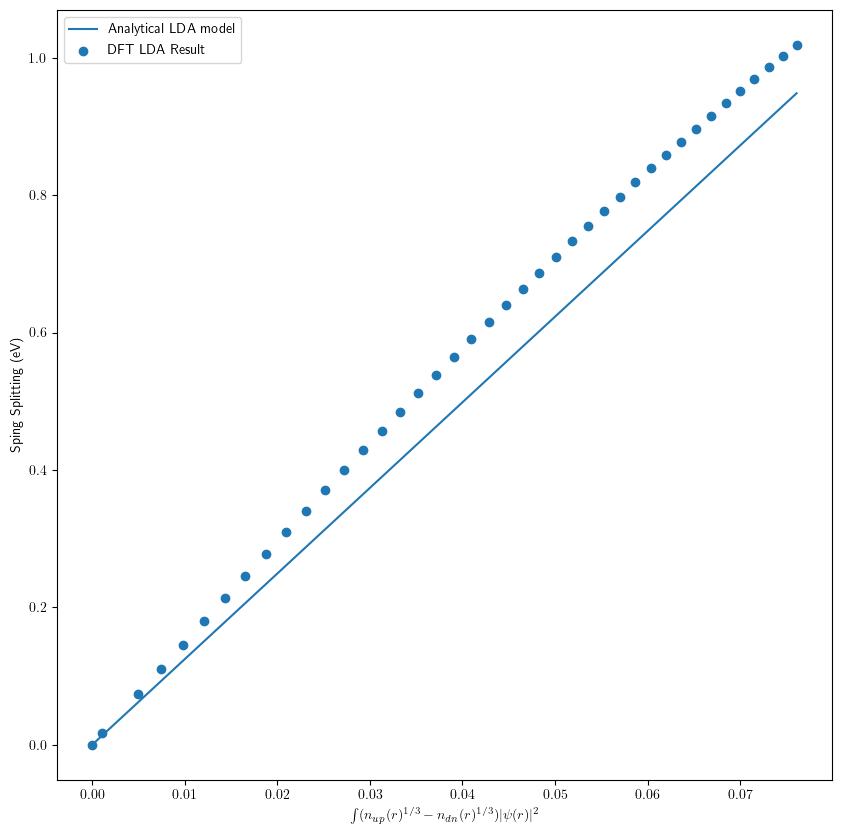

PyObject <matplotlib.legend.Legend object at 0x7f50cfeb19d0>

In [20]:
figure(figsize=(10, 10))
scatter(x, splits, label="DFT LDA Result")

plot(x, x*0.458*1/eV, label="Analytical LDA model")
ylabel("Sping Splitting (eV)")

xlabel(L"\int (n_{up}(r)^{1/3}-n_{dn}(r)^{1/3})|\psi(r)|^2")
legend()

In [66]:
minimum(splits)

1.3586107207030906e-6